In [2]:
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
import proplot as pplt
sys.path.insert(0,'..')
warnings.filterwarnings('ignore')
pplt.rc.update({
    'tick.minor':False,
    'savefig.dpi':300,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'legend.fontsize':9})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
MODELSDIR = CONFIGS['filepaths']['models']
SRCONFIG  = CONFIGS['experiments']['sr']
SEEDS     = SRCONFIG['seeds']

In [4]:
def load_equations(runname):
    seedframes = {}
    for seed in SEEDS:
        filepath = os.path.join(MODELSDIR,'sr',f'{runname}_{seed}_equations.csv')
        df = pd.read_csv(filepath)
        df['seed'] = seed
        seedframes[seed] = df
    return seedframes

def union_pareto(seedframes):
    rows = []
    for seed,df in seedframes.items():
        for _,row in df.iterrows():
            rows.append(dict(
                seed=seed,
                complexity=int(row['complexity']),
                loss=float(row['loss']),
                equation=str(row['equation'])))
    return pd.DataFrame(rows).sort_values(['seed','complexity']).reset_index(drop=True)

def print_equation_table(runname):
    seedframes = load_equations(runname)
    if not seedframes:
        print(f'No equations found for {runname}')
        return
    table = union_pareto(seedframes)
    print(f'\n=== {runname} ===')
    print(table.to_string(index=False,max_colwidth=80))

In [5]:
for runname in SRCONFIG['runs']:
    print_equation_table(runname)


=== sr_gauss_all ===
 seed  complexity     loss                                                                         equation
   42           1 0.998213                                                                     0.0017117715
   42           2 0.679273                                                                               rh
   42           4 0.650225                                                                         cube(rh)
   42           6 0.631149                                                             cube(rh) * 1.3392863
   42           8 0.622777                                               cube(rh + 0.16085187) - 0.18720216
   42           9 0.603885                                        (rh + 0.60264933) - abs(shf - -0.4472464)
   42          10 0.579758                                        ((thetae + rh) - thetaestar) + -1.0864134
   42          11 0.500468                   (thetae + ((thetaestar * -1.4365331) + -1.0962576)) * 4.299591
   42 

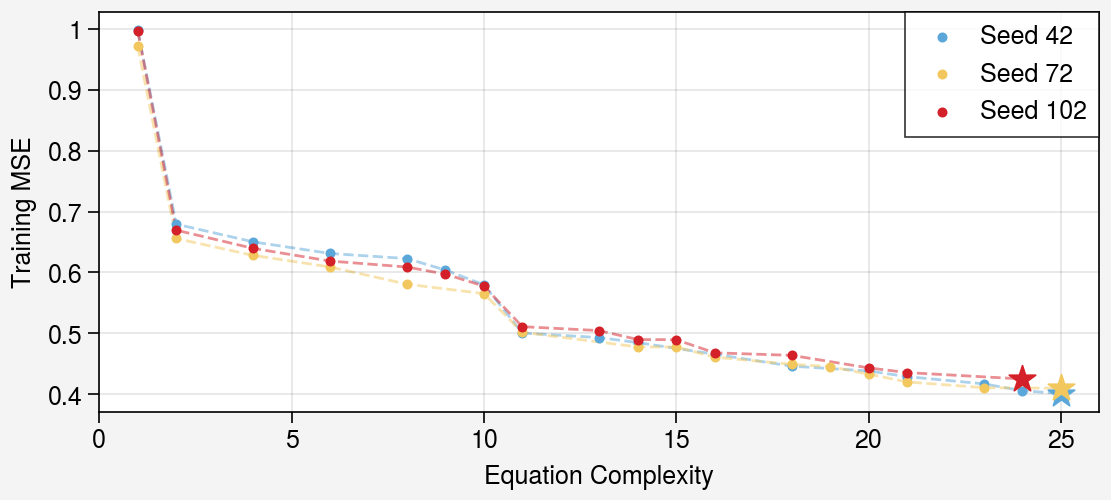

In [7]:
colors = ['#5BA7DA','#F2C85E','#D42028']
for runname in SRCONFIG['runs']:
    seedframes = load_equations(runname)    
    fig,ax = pplt.subplots(refwidth=5,refheight=2)
    ax.format(xlabel='Equation Complexity',xlim=(0,26),ylabel='Training MSE',grid=True)
    for i,(seed,df) in enumerate(sorted(seedframes.items())):
        df      = df.sort_values('complexity')
        bestidx = df['loss'].idxmin()
        color   = colors[i%len(colors)]
        ax.plot(df['complexity'],df['loss'],color=color,alpha=0.5,linewidth=1,linestyle='--',zorder=1,label='')
        ax.scatter(df['complexity'],df['loss'],color=color,marker='.',zorder=3,label=f'Seed {seed}')
        ax.scatter([df.loc[bestidx,'complexity']],[df.loc[bestidx,'loss']],color=color,marker='*',markersize=100,zorder=4)
    ax.legend(loc='ur',ncols=1)
    pplt.show()
    # fig.save('../figs/fig_S2.jpg')